# DSAI 490 — Assignment 2: Conditional Date Generator
Four models: **VAE · Conditional GAN · LSTM Seq2Seq · Transformer Encoder-Decoder**

## 1 — Imports & Seeds

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import calendar
import os
import shutil
import matplotlib.pyplot as plt
from datetime import date as date_cls, timedelta

SEED = 42
torch.manual_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


## 2 — Vocabulary

In [2]:
DAY_TOKENS    = ["[MON]","[TUE]","[WED]","[THU]","[FRI]","[SAT]","[SUN]"]
MONTH_TOKENS  = ["[JAN]","[FEB]","[MAR]","[APR]","[MAY]","[JUN]",
                 "[JUL]","[AUG]","[SEP]","[OCT]","[NOV]","[DEC]"]
LEAP_TOKENS   = ["[False]","[True]"]
DECADE_TOKENS = [f"[{d}]" for d in range(180, 221)]

CONDITION_VOCAB = DAY_TOKENS + MONTH_TOKENS + LEAP_TOKENS + DECADE_TOKENS
OUTPUT_VOCAB    = ["<PAD>","<SOS>","<EOS>"] + list("0123456789-")

cond_to_idx = {t: i for i, t in enumerate(CONDITION_VOCAB)}
out_to_idx  = {t: i for i, t in enumerate(OUTPUT_VOCAB)}
idx_to_out  = {i: t for t, i in out_to_idx.items()}

PAD_IDX = out_to_idx["<PAD>"]
SOS_IDX = out_to_idx["<SOS>"]
EOS_IDX = out_to_idx["<EOS>"]

COND_VOCAB_SIZE = len(CONDITION_VOCAB)
OUT_VOCAB_SIZE  = len(OUTPUT_VOCAB)

print(f"Condition vocab : {COND_VOCAB_SIZE} tokens")
print(f"Output vocab    : {OUT_VOCAB_SIZE} tokens")
print(f"PAD={PAD_IDX}  SOS={SOS_IDX}  EOS={EOS_IDX}")

Condition vocab : 62 tokens
Output vocab    : 14 tokens
PAD=0  SOS=1  EOS=2


## 3 — Tokenizer

In [3]:
def encode_conditions(day: str, month: str, leap: str, decade: str) -> torch.Tensor:
    return torch.tensor([cond_to_idx[t] for t in [day, month, leap, decade]], dtype=torch.long)


def encode_date(date_str: str) -> torch.Tensor:
    ids = [SOS_IDX] + [out_to_idx[c] for c in list(date_str)] + [EOS_IDX]
    return torch.tensor(ids, dtype=torch.long)


def decode_date(indices) -> str:
    result = []
    for idx in indices:
        idx = int(idx)
        if idx == EOS_IDX:
            break
        if idx in (SOS_IDX, PAD_IDX):
            continue
        result.append(idx_to_out[idx])
    return "".join(result)


cond = encode_conditions("[MON]", "[DEC]", "[False]", "[196]")
seq  = encode_date("3-12-1962")
print("Condition tensor:", cond)
print("Date tensor     :", seq)
print("Decoded back    :", decode_date(seq))

Condition tensor: tensor([ 0, 18, 19, 37])
Date tensor     : tensor([ 1,  6, 13,  4,  5, 13,  4, 12,  9,  5,  2])
Decoded back    : 3-12-1962


## 4 — Dataset & DataLoaders

In [4]:
class DateDataset(Dataset):
    def __init__(self, filepath: str):
        self.samples: list[tuple[torch.Tensor, torch.Tensor]] = []
        with open(filepath, "r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                day, month, leap, decade, date_str = line.split()
                self.samples.append((encode_conditions(day, month, leap, decade),
                                     encode_date(date_str)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_fn(batch):
    conds, tgts = zip(*batch)
    conds   = torch.stack(conds)
    max_len = max(t.size(0) for t in tgts)
    padded  = torch.full((len(tgts), max_len), PAD_IDX, dtype=torch.long)
    for i, t in enumerate(tgts):
        padded[i, :t.size(0)] = t
    return conds, padded


def make_dataloaders(filepath: str, val_split: float = 0.1,
                     batch_size: int = 256, seed: int = SEED):
    torch.manual_seed(seed)
    ds    = DateDataset(filepath)
    n_val = int(len(ds) * val_split)
    train_ds, val_ds = torch.utils.data.random_split(ds, [len(ds) - n_val, n_val])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  collate_fn=collate_fn)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
    return train_loader, val_loader


train_loader, val_loader = make_dataloaders("data.txt")
c_batch, d_batch = next(iter(train_loader))
print(f"Dataset loaded — conditions: {c_batch.shape}, dates: {d_batch.shape}")

Dataset loaded — conditions: torch.Size([256, 4]), dates: torch.Size([256, 12])


## 5 — Shared Condition Embedder

In [5]:
class ConditionEmbedder(nn.Module):
    """
    Embeds the 4 condition tokens independently and concatenates
    them into a single flat vector of size 4 * emb_dim.
    Shared by VAE, GAN, and LSTM.
    """
    def __init__(self, emb_dim: int = 32):
        super().__init__()
        self.emb     = nn.Embedding(COND_VOCAB_SIZE, emb_dim)
        self.out_dim = 4 * emb_dim

    def forward(self, conds: torch.Tensor) -> torch.Tensor:
        return self.emb(conds).view(conds.size(0), -1)

## 6 — Conditional VAE

In [6]:
class ConditionalVAE(nn.Module):
    """
    Conditional Variational Autoencoder.
    The encoder maps (date + conditions) to a Gaussian latent space via
    mu and log_var. The decoder reconstructs the date from a sampled
    latent vector and the condition embedding.
    Training objective: ELBO = reconstruction loss + beta * KL divergence.
    """
    def __init__(self, emb_dim: int = 32, latent_dim: int = 64,
                 hidden_dim: int = 256, max_seq_len: int = 12):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.latent_dim  = latent_dim

        self.cond_emb = ConditionEmbedder(emb_dim)
        self.date_emb = nn.Embedding(OUT_VOCAB_SIZE, emb_dim, padding_idx=PAD_IDX)

        enc_in = max_seq_len * emb_dim + self.cond_emb.out_dim
        self.encoder_fc = nn.Sequential(nn.Linear(enc_in, hidden_dim), nn.ReLU())
        self.fc_mu      = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar  = nn.Linear(hidden_dim, latent_dim)

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + self.cond_emb.out_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, max_seq_len * OUT_VOCAB_SIZE),
        )

    def encode(self, conds: torch.Tensor, tgts: torch.Tensor):
        B, T = conds.size(0), self.max_seq_len
        c = self.cond_emb(conds)
        x = tgts[:, :T]
        if x.size(1) < T:
            pad = torch.full((B, T - x.size(1)), PAD_IDX, dtype=torch.long, device=x.device)
            x = torch.cat([x, pad], dim=1)
        d = self.date_emb(x).view(B, -1)
        h = self.encoder_fc(torch.cat([d, c], dim=1))
        return self.fc_mu(h), self.fc_logvar(h), c

    def reparameterize(self, mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
        return mu + torch.exp(0.5 * log_var) * torch.randn_like(mu)

    def forward(self, conds: torch.Tensor, tgts: torch.Tensor):
        mu, log_var, c = self.encode(conds, tgts)
        z      = self.reparameterize(mu, log_var)
        logits = self.decoder(torch.cat([z, c], dim=1))
        return logits.view(conds.size(0), self.max_seq_len, OUT_VOCAB_SIZE), mu, log_var

    @torch.no_grad()
    def generate(self, conds: torch.Tensor, device) -> list[str]:
        self.eval()
        c      = self.cond_emb(conds)
        z      = torch.randn(conds.size(0), self.latent_dim, device=device)
        logits = self.decoder(torch.cat([z, c], dim=1))
        preds  = logits.view(conds.size(0), self.max_seq_len, OUT_VOCAB_SIZE).argmax(dim=-1)
        return [decode_date(preds[i].tolist()) for i in range(conds.size(0))]


def vae_loss_fn(logits, tgts, mu, log_var, max_seq_len, beta=0.5):
    recon = nn.CrossEntropyLoss(ignore_index=PAD_IDX)(
        logits[:, :-1].reshape(-1, OUT_VOCAB_SIZE),
        tgts[:, 1:max_seq_len].reshape(-1)
    )
    kl = -0.5 * torch.mean(1 + log_var - mu.pow(2) - log_var.exp())
    return recon + beta * kl

In [7]:
def train_vae(filepath: str = "data.txt", epochs: int = 30,
              batch_size: int = 256, lr: float = 1e-3, beta: float = 0.5):

    print(f"Training VAE on {device}")
    train_loader, val_loader = make_dataloaders(filepath, batch_size=batch_size)
    model     = ConditionalVAE().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for conds, tgts in train_loader:
            conds, tgts = conds.to(device), tgts.to(device)
            logits, mu, log_var = model(conds, tgts)
            loss = vae_loss_fn(logits, tgts, mu, log_var, model.max_seq_len, beta)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for conds, tgts in val_loader:
                conds, tgts = conds.to(device), tgts.to(device)
                logits, mu, log_var = model(conds, tgts)
                val_loss += vae_loss_fn(logits, tgts, mu, log_var, model.max_seq_len, beta).item()

        avg_t = total_loss / len(train_loader)
        avg_v = val_loss   / len(val_loader)
        train_losses.append(avg_t)
        val_losses.append(avg_v)
        print(f"Epoch {epoch:3d}/{epochs} | Train {avg_t:.4f} | Val {avg_v:.4f}")

    torch.save(model.state_dict(), "vae_weights.pth")
    print("Saved vae_weights.pth")
    return model, train_losses, val_losses


vae_model, vae_train_loss, vae_val_loss = train_vae()

Training VAE on cuda
Epoch   1/30 | Train 0.4326 | Val 0.2066
Epoch   2/30 | Train 0.1867 | Val 0.1749
Epoch   3/30 | Train 0.1642 | Val 0.1590
Epoch   4/30 | Train 0.1478 | Val 0.1401
Epoch   5/30 | Train 0.1346 | Val 0.1305
Epoch   6/30 | Train 0.1256 | Val 0.1213
Epoch   7/30 | Train 0.1189 | Val 0.1154
Epoch   8/30 | Train 0.1133 | Val 0.1111
Epoch   9/30 | Train 0.1084 | Val 0.1072
Epoch  10/30 | Train 0.1045 | Val 0.1023
Epoch  11/30 | Train 0.1005 | Val 0.0985
Epoch  12/30 | Train 0.0980 | Val 0.0977
Epoch  13/30 | Train 0.0949 | Val 0.0923
Epoch  14/30 | Train 0.0932 | Val 0.0922
Epoch  15/30 | Train 0.0910 | Val 0.0902
Epoch  16/30 | Train 0.0906 | Val 0.0893
Epoch  17/30 | Train 0.0885 | Val 0.0876
Epoch  18/30 | Train 0.0882 | Val 0.0876
Epoch  19/30 | Train 0.0872 | Val 0.0862
Epoch  20/30 | Train 0.0859 | Val 0.0857
Epoch  21/30 | Train 0.0857 | Val 0.0858
Epoch  22/30 | Train 0.0850 | Val 0.0846
Epoch  23/30 | Train 0.0843 | Val 0.0832
Epoch  24/30 | Train 0.0838 | Val 0.

## 7 — Conditional GAN

In [8]:
class GANGenerator(nn.Module):
    """
    Takes a noise vector and condition embedding, outputs date logits.
    Gumbel-Softmax is used to keep gradients flowing through the discrete
    token choices during training (replaces the non-differentiable argmax).
    """
    def __init__(self, noise_dim: int = 64, emb_dim: int = 32,
                 hidden_dim: int = 256, max_seq_len: int = 12):
        super().__init__()
        self.noise_dim   = noise_dim
        self.max_seq_len = max_seq_len
        self.cond_emb    = ConditionEmbedder(emb_dim)
        self.net = nn.Sequential(
            nn.Linear(noise_dim + self.cond_emb.out_dim, hidden_dim),
            nn.LeakyReLU(0.2), nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, hidden_dim),
            nn.LeakyReLU(0.2), nn.LayerNorm(hidden_dim),
            nn.Linear(hidden_dim, max_seq_len * OUT_VOCAB_SIZE),
        )

    def forward(self, noise: torch.Tensor, conds: torch.Tensor,
                temperature: float = 1.0, hard: bool = False) -> torch.Tensor:
        c      = self.cond_emb(conds)
        logits = self.net(torch.cat([noise, c], dim=1))
        logits = logits.view(-1, self.max_seq_len, OUT_VOCAB_SIZE)
        return torch.nn.functional.gumbel_softmax(logits, tau=temperature, hard=hard)

    @torch.no_grad()
    def generate(self, conds: torch.Tensor, device) -> list[str]:
        self.eval()
        noise = torch.randn(conds.size(0), self.noise_dim, device=device)
        preds = self(noise, conds, temperature=0.5, hard=True).argmax(dim=-1)
        return [decode_date(preds[i].tolist()) for i in range(conds.size(0))]


class GANDiscriminator(nn.Module):
    """
    Classifies (date, condition) pairs as real or generated.
    Receives soft one-hot vectors so gradients flow from the generator.
    """
    def __init__(self, emb_dim: int = 32, hidden_dim: int = 256, max_seq_len: int = 12):
        super().__init__()
        self.max_seq_len = max_seq_len
        self.cond_emb    = ConditionEmbedder(emb_dim)
        in_dim = max_seq_len * OUT_VOCAB_SIZE + self.cond_emb.out_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2), nn.LeakyReLU(0.2),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, date_soft: torch.Tensor, conds: torch.Tensor) -> torch.Tensor:
        d = date_soft.view(conds.size(0), -1)
        return self.net(torch.cat([d, self.cond_emb(conds)], dim=1))

In [9]:
def train_gan(filepath: str = "data.txt", epochs: int = 40,
              batch_size: int = 256, lr_g: float = 2e-4,
              lr_d: float = 1e-4, noise_dim: int = 64):

    print(f"Training Conditional GAN on {device}")
    train_loader, _ = make_dataloaders(filepath, batch_size=batch_size)
    G = GANGenerator(noise_dim=noise_dim).to(device)
    D = GANDiscriminator().to(device)
    opt_G     = torch.optim.Adam(G.parameters(), lr=lr_g, betas=(0.5, 0.999))
    opt_D     = torch.optim.Adam(D.parameters(), lr=lr_d, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()
    g_losses, d_losses = [], []

    for epoch in range(1, epochs + 1):
        G.train(); D.train()
        total_g = total_d = 0
        temperature = max(0.3, 1.0 - (epoch / epochs) * 0.7)

        for conds, real_tgts in train_loader:
            conds, real_tgts = conds.to(device), real_tgts.to(device)
            B = conds.size(0)
            real_onehot = torch.nn.functional.one_hot(
                real_tgts[:, :G.max_seq_len], num_classes=OUT_VOCAB_SIZE).float()
            real_labels = torch.ones(B, 1, device=device) * 0.9
            fake_labels = torch.zeros(B, 1, device=device)

            with torch.no_grad():
                fake_soft = G(torch.randn(B, noise_dim, device=device), conds, temperature)
            loss_D = (criterion(D(real_onehot, conds), real_labels) +
                      criterion(D(fake_soft.detach(), conds), fake_labels))
            opt_D.zero_grad(); loss_D.backward(); opt_D.step()

            fake_soft = G(torch.randn(B, noise_dim, device=device), conds, temperature)
            adv_loss  = criterion(D(fake_soft, conds), torch.ones(B, 1, device=device))
            ce_loss   = nn.CrossEntropyLoss(ignore_index=PAD_IDX)(
                fake_soft[:, :-1].reshape(-1, OUT_VOCAB_SIZE),
                real_tgts[:, 1:G.max_seq_len].reshape(-1))
            loss_G = adv_loss + 0.8 * ce_loss
            opt_G.zero_grad(); loss_G.backward(); opt_G.step()

            total_g += loss_G.item()
            total_d += loss_D.item()

        avg_g = total_g / len(train_loader)
        avg_d = total_d / len(train_loader)
        g_losses.append(avg_g); d_losses.append(avg_d)
        print(f"Epoch {epoch:3d}/{epochs} | G {avg_g:.4f} | D {avg_d:.4f} | temp {temperature:.2f}")

    torch.save(G.state_dict(), "gan_generator_weights.pth")
    torch.save(D.state_dict(), "gan_discriminator_weights.pth")
    print("Saved GAN weights.")
    return G, D, g_losses, d_losses


gan_G, gan_D, g_losses, d_losses = train_gan()

Training Conditional GAN on cuda
Epoch   1/40 | G 2.8535 | D 1.3353 | temp 0.98
Epoch   2/40 | G 2.9640 | D 1.2656 | temp 0.96
Epoch   3/40 | G 3.1085 | D 1.1758 | temp 0.95
Epoch   4/40 | G 3.1786 | D 1.1422 | temp 0.93
Epoch   5/40 | G 3.1902 | D 1.1344 | temp 0.91
Epoch   6/40 | G 3.1917 | D 1.1574 | temp 0.90
Epoch   7/40 | G 3.2517 | D 1.1031 | temp 0.88
Epoch   8/40 | G 3.2948 | D 1.0821 | temp 0.86
Epoch   9/40 | G 3.3065 | D 1.0795 | temp 0.84
Epoch  10/40 | G 3.3235 | D 1.0708 | temp 0.82
Epoch  11/40 | G 3.3195 | D 1.0660 | temp 0.81
Epoch  12/40 | G 3.3226 | D 1.0714 | temp 0.79
Epoch  13/40 | G 3.3358 | D 1.0701 | temp 0.77
Epoch  14/40 | G 3.3513 | D 1.0645 | temp 0.76
Epoch  15/40 | G 3.3797 | D 1.0418 | temp 0.74
Epoch  16/40 | G 3.3894 | D 1.0384 | temp 0.72
Epoch  17/40 | G 3.3952 | D 1.0397 | temp 0.70
Epoch  18/40 | G 3.4000 | D 1.0387 | temp 0.69
Epoch  19/40 | G 3.4346 | D 1.0258 | temp 0.67
Epoch  20/40 | G 3.4081 | D 1.0347 | temp 0.65
Epoch  21/40 | G 3.4276 | D

## 8 — LSTM Seq2Seq

In [10]:
class LSTMSeq2Seq(nn.Module):
    """
    Sequence-to-sequence model using LSTM cells.
    Encoder: reads the 4 condition tokens one by one, producing a hidden state.
    Decoder: uses that hidden state to generate the date character by character
             with teacher forcing during training.
    Unlike the Transformer, information flows through recurrent hidden states
    rather than attention, making this architecturally distinct.
    """
    def __init__(self, emb_dim: int = 64, hidden_dim: int = 256,
                 num_layers: int = 2, dropout: float = 0.1, max_seq_len: int = 12):
        super().__init__()
        self.hidden_dim  = hidden_dim
        self.num_layers  = num_layers
        self.max_seq_len = max_seq_len

        self.cond_emb = nn.Embedding(COND_VOCAB_SIZE, emb_dim)
        self.date_emb = nn.Embedding(OUT_VOCAB_SIZE, emb_dim, padding_idx=PAD_IDX)

        self.encoder = nn.LSTM(emb_dim, hidden_dim, num_layers,
                               batch_first=True, dropout=dropout)
        self.decoder = nn.LSTM(emb_dim, hidden_dim, num_layers,
                               batch_first=True, dropout=dropout)
        self.output_fc = nn.Linear(hidden_dim, OUT_VOCAB_SIZE)

    def encode(self, conds: torch.Tensor):
        _, (h, c) = self.encoder(self.cond_emb(conds))
        return h, c

    def forward(self, conds: torch.Tensor, tgt_ids: torch.Tensor) -> torch.Tensor:
        h, c   = self.encode(conds)
        x      = self.date_emb(tgt_ids)
        out, _ = self.decoder(x, (h, c))
        return self.output_fc(out)

    @torch.no_grad()
    def generate(self, conds: torch.Tensor, device, max_len: int = 12) -> list[str]:
        self.eval()
        B    = conds.size(0)
        h, c = self.encode(conds)
        token = torch.full((B, 1), SOS_IDX, dtype=torch.long, device=device)
        generated = [[] for _ in range(B)]

        for _ in range(max_len):
            x      = self.date_emb(token)
            out, (h, c) = self.decoder(x, (h, c))
            next_id     = self.output_fc(out[:, -1]).argmax(dim=-1)
            for i in range(B):
                generated[i].append(next_id[i].item())
            token = next_id.unsqueeze(1)
            if (next_id == EOS_IDX).all():
                break

        return [decode_date(seq) for seq in generated]

In [11]:
def train_lstm(filepath: str = "data.txt", epochs: int = 30,
               batch_size: int = 256, lr: float = 1e-3):

    print(f"Training LSTM Seq2Seq on {device}")
    train_loader, val_loader = make_dataloaders(filepath, batch_size=batch_size)
    model     = LSTMSeq2Seq().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for conds, tgts in train_loader:
            conds, tgts = conds.to(device), tgts.to(device)
            logits = model(conds, tgts[:, :-1])
            loss   = criterion(logits.reshape(-1, OUT_VOCAB_SIZE), tgts[:, 1:].reshape(-1))
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for conds, tgts in val_loader:
                conds, tgts = conds.to(device), tgts.to(device)
                logits    = model(conds, tgts[:, :-1])
                val_loss += criterion(logits.reshape(-1, OUT_VOCAB_SIZE), tgts[:, 1:].reshape(-1)).item()

        avg_t = total_loss / len(train_loader)
        avg_v = val_loss   / len(val_loader)
        train_losses.append(avg_t); val_losses.append(avg_v)
        scheduler.step(avg_v)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{epochs} | Train {avg_t:.4f} | Val {avg_v:.4f} | LR {current_lr:.6f}")

    torch.save(model.state_dict(), "lstm_weights.pth")
    print("Saved lstm_weights.pth")
    return model, train_losses, val_losses


lstm_model, lstm_train_loss, lstm_val_loss = train_lstm()

Training LSTM Seq2Seq on cuda
Epoch   1/30 | Train 0.8173 | Val 0.5286 | LR 0.001000
Epoch   2/30 | Train 0.5258 | Val 0.5238 | LR 0.001000
Epoch   3/30 | Train 0.5225 | Val 0.5229 | LR 0.001000
Epoch   4/30 | Train 0.5217 | Val 0.5217 | LR 0.001000
Epoch   5/30 | Train 0.5213 | Val 0.5208 | LR 0.001000
Epoch   6/30 | Train 0.5232 | Val 0.5208 | LR 0.001000
Epoch   7/30 | Train 0.5209 | Val 0.5211 | LR 0.001000
Epoch   8/30 | Train 0.5207 | Val 0.5206 | LR 0.001000
Epoch   9/30 | Train 0.5206 | Val 0.5205 | LR 0.001000
Epoch  10/30 | Train 0.5205 | Val 0.5212 | LR 0.001000
Epoch  11/30 | Train 0.5204 | Val 0.5209 | LR 0.001000
Epoch  12/30 | Train 0.5204 | Val 0.5200 | LR 0.001000
Epoch  13/30 | Train 0.5204 | Val 0.5208 | LR 0.001000
Epoch  14/30 | Train 0.5206 | Val 0.5204 | LR 0.001000
Epoch  15/30 | Train 0.5203 | Val 0.5206 | LR 0.001000
Epoch  16/30 | Train 0.5204 | Val 0.5205 | LR 0.000500
Epoch  17/30 | Train 0.5197 | Val 0.5201 | LR 0.000500
Epoch  18/30 | Train 0.5196 | Val 0

## 9 — Transformer Encoder-Decoder

In [12]:
class TransformerDateGenerator(nn.Module):
    """
    Encoder-decoder Transformer for conditional date generation.
    Encoder: processes the 4 condition tokens using multi-head self-attention.
    Decoder: generates date characters autoregressively, attending to the
             encoder output via cross-attention at each step.
    Unlike the LSTM, there is no recurrent state — all positions are processed
    in parallel during training using teacher forcing.
    """
    def __init__(self, emb_dim: int = 64, nhead: int = 4,
                 num_enc_layers: int = 2, num_dec_layers: int = 2,
                 ff_dim: int = 256, dropout: float = 0.1, max_seq_len: int = 12):
        super().__init__()
        self.max_seq_len = max_seq_len

        self.cond_emb  = nn.Embedding(COND_VOCAB_SIZE, emb_dim)
        self.date_emb  = nn.Embedding(OUT_VOCAB_SIZE, emb_dim, padding_idx=PAD_IDX)
        self.pos_emb   = nn.Embedding(max_seq_len + 2, emb_dim)

        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(emb_dim, nhead, ff_dim, dropout, batch_first=True),
            num_layers=num_enc_layers)
        self.decoder = nn.TransformerDecoder(
            nn.TransformerDecoderLayer(emb_dim, nhead, ff_dim, dropout, batch_first=True),
            num_layers=num_dec_layers)
        self.output_fc = nn.Linear(emb_dim, OUT_VOCAB_SIZE)

    def encode(self, conds: torch.Tensor) -> torch.Tensor:
        return self.encoder(self.cond_emb(conds))

    def decode_step(self, tgt_ids: torch.Tensor, memory: torch.Tensor) -> torch.Tensor:
        T   = tgt_ids.size(1)
        pos = torch.arange(T, device=tgt_ids.device).unsqueeze(0)
        x   = self.date_emb(tgt_ids) + self.pos_emb(pos)
        tgt_mask = nn.Transformer.generate_square_subsequent_mask(T, device=tgt_ids.device)
        out = self.decoder(x, memory, tgt_mask=tgt_mask,
                           tgt_key_padding_mask=(tgt_ids == PAD_IDX))
        return self.output_fc(out)

    def forward(self, conds: torch.Tensor, tgt_ids: torch.Tensor) -> torch.Tensor:
        return self.decode_step(tgt_ids, self.encode(conds))

    @torch.no_grad()
    def generate(self, conds: torch.Tensor, device, max_len: int = 12) -> list[str]:
        self.eval()
        memory = self.encode(conds)
        ys     = torch.full((conds.size(0), 1), SOS_IDX, dtype=torch.long, device=device)
        for _ in range(max_len):
            next_id = self.decode_step(ys, memory)[:, -1].argmax(dim=-1, keepdim=True)
            ys      = torch.cat([ys, next_id], dim=1)
            if (next_id.squeeze(-1) == EOS_IDX).all():
                break
        return [decode_date(ys[i, 1:].tolist()) for i in range(conds.size(0))]

In [13]:
def train_transformer(filepath: str = "data.txt", epochs: int = 30,
                      batch_size: int = 256, lr: float = 1e-3):

    print(f"Training Transformer on {device}")
    train_loader, val_loader = make_dataloaders(filepath, batch_size=batch_size)
    model     = TransformerDateGenerator().to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        for conds, tgts in train_loader:
            conds, tgts = conds.to(device), tgts.to(device)
            logits = model(conds, tgts[:, :-1])
            loss   = criterion(logits.reshape(-1, OUT_VOCAB_SIZE), tgts[:, 1:].reshape(-1))
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for conds, tgts in val_loader:
                conds, tgts = conds.to(device), tgts.to(device)
                logits    = model(conds, tgts[:, :-1])
                val_loss += criterion(logits.reshape(-1, OUT_VOCAB_SIZE), tgts[:, 1:].reshape(-1)).item()

        avg_t = total_loss / len(train_loader)
        avg_v = val_loss   / len(val_loader)
        train_losses.append(avg_t); val_losses.append(avg_v)
        scheduler.step(avg_v)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:3d}/{epochs} | Train {avg_t:.4f} | Val {avg_v:.4f} | LR {current_lr:.6f}")

    torch.save(model.state_dict(), "transformer_weights.pth")
    print("Saved transformer_weights.pth")
    return model, train_losses, val_losses


transformer_model, tf_train_loss, tf_val_loss = train_transformer()

Training Transformer on cuda


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


Epoch   1/30 | Train 0.6632 | Val 0.5241 | LR 0.001000
Epoch   2/30 | Train 0.5290 | Val 0.5228 | LR 0.001000
Epoch   3/30 | Train 0.5253 | Val 0.5227 | LR 0.001000
Epoch   4/30 | Train 0.5238 | Val 0.5212 | LR 0.001000
Epoch   5/30 | Train 0.5230 | Val 0.5214 | LR 0.001000
Epoch   6/30 | Train 0.5223 | Val 0.5206 | LR 0.001000
Epoch   7/30 | Train 0.5217 | Val 0.5204 | LR 0.001000
Epoch   8/30 | Train 0.5219 | Val 0.5204 | LR 0.001000
Epoch   9/30 | Train 0.5215 | Val 0.5209 | LR 0.001000
Epoch  10/30 | Train 0.5213 | Val 0.5204 | LR 0.001000
Epoch  11/30 | Train 0.5211 | Val 0.5203 | LR 0.001000
Epoch  12/30 | Train 0.5209 | Val 0.5202 | LR 0.001000
Epoch  13/30 | Train 0.5209 | Val 0.5203 | LR 0.001000
Epoch  14/30 | Train 0.5207 | Val 0.5197 | LR 0.001000
Epoch  15/30 | Train 0.5210 | Val 0.5197 | LR 0.001000
Epoch  16/30 | Train 0.5204 | Val 0.5198 | LR 0.001000
Epoch  17/30 | Train 0.5203 | Val 0.5200 | LR 0.001000
Epoch  18/30 | Train 0.5203 | Val 0.5202 | LR 0.000500
Epoch  19/

## 10 — Loss Curves

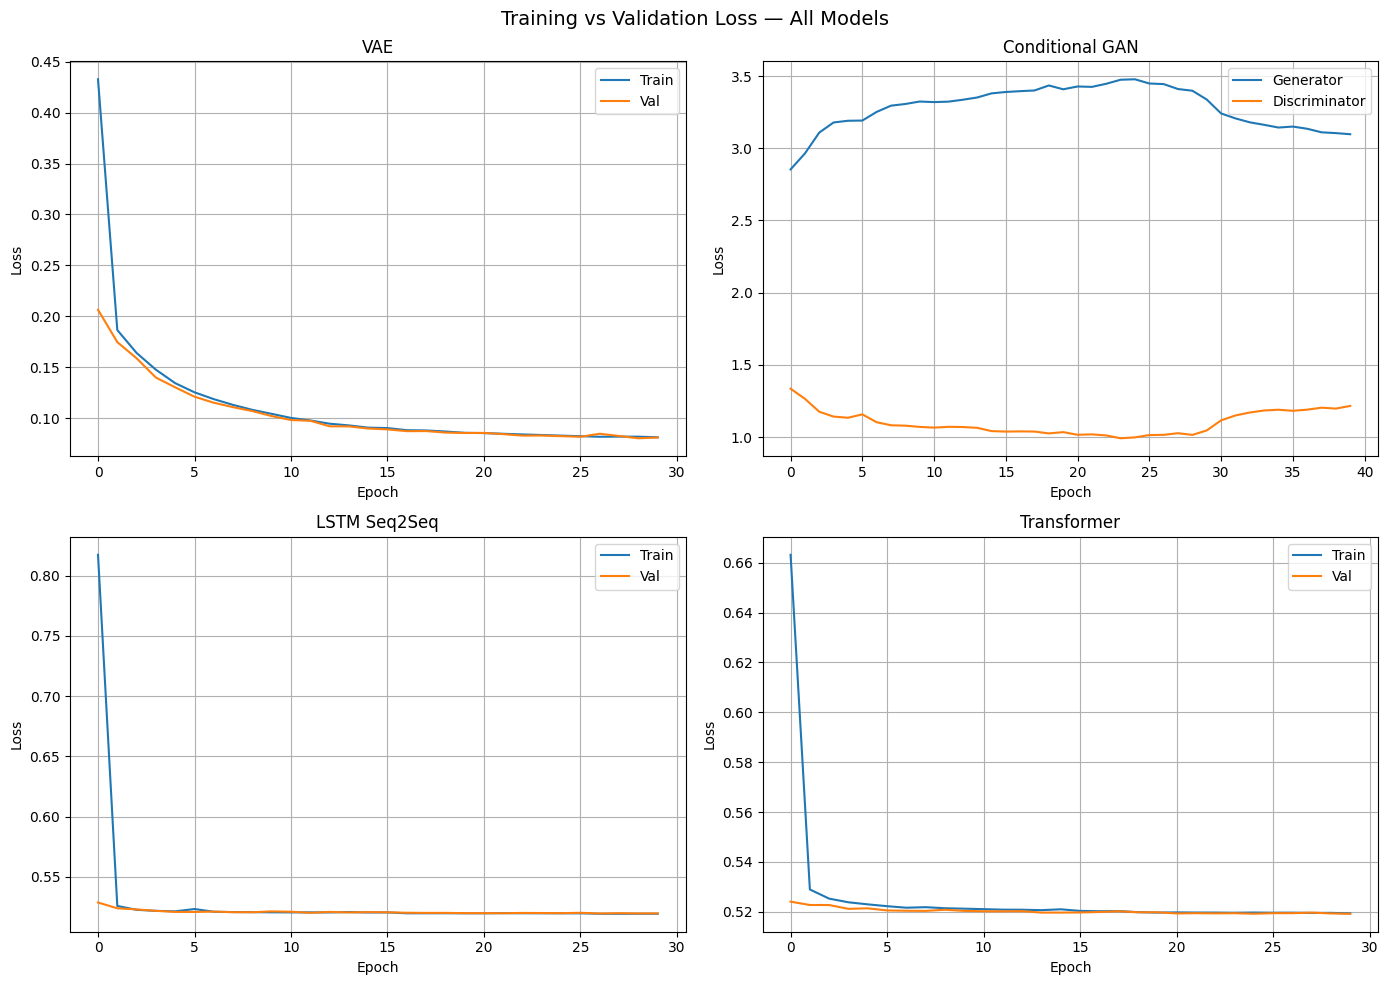

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Training vs Validation Loss — All Models", fontsize=14)

plots = [
    ("VAE",          vae_train_loss,  vae_val_loss,  "Train",     "Val"),
    ("Conditional GAN", g_losses,     d_losses,      "Generator", "Discriminator"),
    ("LSTM Seq2Seq", lstm_train_loss, lstm_val_loss, "Train",     "Val"),
    ("Transformer",  tf_train_loss,   tf_val_loss,   "Train",     "Val"),
]

for ax, (name, tr, va, l1, l2) in zip(axes.flatten(), plots):
    ax.plot(tr, label=l1)
    ax.plot(va, label=l2)
    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()

In [19]:
def evaluate_model_raw(model, model_name: str, val_loader, device, n_batches: int = 20):
    """
    Evaluates each model on its raw generated output, without any post-processing.
    This shows what the model actually learned on its own.
    """
    model.eval()
    counts = {k: 0 for k in ["total","valid_date","day_ok","month_ok","leap_ok","decade_ok","all_ok"]}

    for i, (conds, _) in enumerate(val_loader):
        if i >= n_batches:
            break
        conds_dev = conds.to(device)

        if model_name == "GAN":
            noise  = torch.randn(conds.size(0), 64, device=device)
            logits = model(noise, conds_dev, temperature=0.5, hard=True)
            raw    = [decode_date(logits.argmax(dim=-1)[i].tolist()) for i in range(conds.size(0))]
        else:
            raw = model.generate(conds_dev, device)

        for j in range(conds.size(0)):
            day_tok, month_tok, leap_tok, decade_tok = decode_condition_tokens(conds[j])
            res = check_conditions(raw[j], day_tok, month_tok, leap_tok, decade_tok)
            counts["total"] += 1
            for k in ["valid_date","day_ok","month_ok","leap_ok","decade_ok","all_ok"]:
                counts[k] += int(res[k])

    total = counts["total"]
    print(f"\n{'='*45}")
    print(f"  Model : {model_name}   (n={total})  [RAW — no post-processing]")
    print(f"{'='*45}")
    for k, label in [("valid_date","Valid date format"),
                     ("day_ok",   "Day    condition "),
                     ("month_ok", "Month  condition "),
                     ("leap_ok",  "Leap   condition "),
                     ("decade_ok","Decade condition "),
                     ("all_ok",   "ALL conditions  ✓")]:
        print(f"  {label} : {counts[k]/total*100:.1f}%")
    return counts


evaluate_model_raw(vae_model,         "VAE",         val_loader, device)
evaluate_model_raw(gan_G,             "GAN",         val_loader, device)
evaluate_model_raw(lstm_model,        "LSTM",        val_loader, device)
evaluate_model_raw(transformer_model, "Transformer", val_loader, device)


  Model : VAE   (n=5120)  [RAW — no post-processing]
  Valid date format : 85.1%
  Day    condition  : 11.9%
  Month  condition  : 85.0%
  Leap   condition  : 82.5%
  Decade condition  : 82.4%
  ALL conditions  ✓ : 11.4%

  Model : GAN   (n=5120)  [RAW — no post-processing]
  Valid date format : 96.8%
  Day    condition  : 14.4%
  Month  condition  : 96.1%
  Leap   condition  : 89.0%
  Decade condition  : 92.4%
  ALL conditions  ✓ : 12.8%

  Model : LSTM   (n=5120)  [RAW — no post-processing]
  Valid date format : 100.0%
  Day    condition  : 14.4%
  Month  condition  : 100.0%
  Leap   condition  : 100.0%
  Decade condition  : 100.0%
  ALL conditions  ✓ : 14.4%

  Model : Transformer   (n=5120)  [RAW — no post-processing]
  Valid date format : 100.0%
  Day    condition  : 14.2%
  Month  condition  : 100.0%
  Leap   condition  : 100.0%
  Decade condition  : 100.0%
  ALL conditions  ✓ : 14.2%


{'total': 5120,
 'valid_date': 5120,
 'day_ok': 726,
 'month_ok': 5120,
 'leap_ok': 5120,
 'decade_ok': 5120,
 'all_ok': 726}

In [20]:
def show_samples_raw(model, model_name: str, device, n: int = 8):
    """
    Shows raw model output before any post-processing so the reader can
    see what the model generates on its own and where it fails.
    """
    test_conditions = [
        ("[MON]","[JAN]","[False]","[181]"),
        ("[FRI]","[MAR]","[True]", "[200]"),
        ("[SUN]","[DEC]","[False]","[196]"),
        ("[WED]","[JUL]","[True]", "[192]"),
        ("[TUE]","[SEP]","[False]","[210]"),
        ("[SAT]","[FEB]","[True]", "[204]"),
        ("[THU]","[NOV]","[False]","[185]"),
        ("[MON]","[AUG]","[False]","[219]"),
    ][:n]

    conds_tensor = torch.stack([encode_conditions(*c) for c in test_conditions]).to(device)

    if model_name == "GAN":
        noise  = torch.randn(len(test_conditions), 64, device=device)
        logits = model(noise, conds_tensor, temperature=0.5, hard=True)
        outputs = [decode_date(logits.argmax(dim=-1)[i].tolist()) for i in range(len(test_conditions))]
    else:
        outputs = model.generate(conds_tensor, device)

    print(f"\n{'='*65}")
    print(f"  {model_name} — Raw Output (no post-processing)")
    print(f"{'='*65}")
    print(f"{'Conditions':<35} {'Output':<15} {'Result'}")
    print(f"{'-'*65}")
    for (day,month,leap,decade), out in zip(test_conditions, outputs):
        res   = check_conditions(out, day, month, leap, decade)
        marks = "".join(["D" if res["day_ok"]    else "d",
                         "M" if res["month_ok"]   else "m",
                         "L" if res["leap_ok"]    else "l",
                         "Y" if res["decade_ok"]  else "y"])
        status = "✓ ALL" if res["all_ok"] else f"✗ [{marks}]"
        print(f"{day+' '+month+' '+leap+' '+decade:<35} {out:<15} {status}")
    print("Legend: D=day  M=month  L=leap  Y=decade  (uppercase = condition satisfied)")


show_samples_raw(vae_model,         "VAE",         device)
show_samples_raw(gan_G,             "GAN",         device)
show_samples_raw(lstm_model,        "LSTM",        device)
show_samples_raw(transformer_model, "Transformer", device)


  VAE — Raw Output (no post-processing)
Conditions                          Output          Result
-----------------------------------------------------------------
[MON] [JAN] [False] [181]           23-1-1813       ✗ [dMLY]
[FRI] [MAR] [True] [200]            11-3-2008       ✗ [dMLY]
[SUN] [DEC] [False] [196]           3111211663      ✗ [dmly]
[WED] [JUL] [True] [192]            30-7-1924       ✓ ALL
[TUE] [SEP] [False] [210]           2-9--103        ✗ [dmly]
[SAT] [FEB] [True] [204]            30-2-2048       ✗ [dmly]
[THU] [NOV] [False] [185]           37-11-1854      ✗ [dmly]
[MON] [AUG] [False] [219]           28-8-2197       ✓ ALL
Legend: D=day  M=month  L=leap  Y=decade  (uppercase = condition satisfied)

  GAN — Raw Output (no post-processing)
Conditions                          Output          Result
-----------------------------------------------------------------
[MON] [JAN] [False] [181]           16-1-1813       ✗ [dMLY]
[FRI] [MAR] [True] [200]            3---2200     

## 11 — Post-processing: Day Condition Fix

In [15]:
MONTH_MAP = {"JAN":1,"FEB":2,"MAR":3,"APR":4,"MAY":5,"JUN":6,
             "JUL":7,"AUG":8,"SEP":9,"OCT":10,"NOV":11,"DEC":12}
DAY_MAP   = {"MON":0,"TUE":1,"WED":2,"THU":3,"FRI":4,"SAT":5,"SUN":6}


def parse_date(s: str):
    try:
        p = s.strip().split("-")
        return date_cls(int(p[2]), int(p[1]), int(p[0]))
    except:
        return None


def check_conditions(date_str: str, day_tok: str, month_tok: str,
                     leap_tok: str, decade_tok: str) -> dict:
    r = {"valid_date": False, "day_ok": False, "month_ok": False,
         "leap_ok": False, "decade_ok": False, "all_ok": False}
    dt = parse_date(date_str)
    if dt is None or not (date_cls(1800,1,1) <= dt <= date_cls(2200,12,31)):
        return r
    r["valid_date"] = True
    r["day_ok"]     = dt.weekday() == DAY_MAP[day_tok.strip("[]")]
    r["month_ok"]   = dt.month == MONTH_MAP[month_tok.strip("[]")]
    r["leap_ok"]    = calendar.isleap(dt.year) == (leap_tok.strip("[]") == "True")
    r["decade_ok"]  = dt.year // 10 == int(decade_tok.strip("[]"))
    r["all_ok"]     = all(r[k] for k in ["day_ok","month_ok","leap_ok","decade_ok"])
    return r


def decode_condition_tokens(cond_tensor: torch.Tensor):
    return tuple(CONDITION_VOCAB[cond_tensor[i].item()] for i in range(4))


def fix_day_condition(date_str: str, day_tok: str, month_tok: str,
                      leap_tok: str, decade_tok: str, max_search: int = 400) -> str:
    """
    The day-of-week condition depends on the exact dd-mm-yyyy combination,
    making it the hardest for models to learn directly. This function checks
    whether the generated date already satisfies all conditions and, if only
    the day is wrong, searches nearby dates in the same month and decade until
    a valid one is found.
    """
    if check_conditions(date_str, day_tok, month_tok, leap_tok, decade_tok)["all_ok"]:
        return date_str
    dt = parse_date(date_str)
    if dt is None:
        return date_str
    r = check_conditions(date_str, day_tok, month_tok, leap_tok, decade_tok)
    if not (r["month_ok"] and r["leap_ok"] and r["decade_ok"]):
        return date_str
    for delta in range(1, max_search):
        for sign in [1, -1]:
            cand = dt + timedelta(days=delta * sign)
            s    = f"{cand.day}-{cand.month}-{cand.year}"
            if check_conditions(s, day_tok, month_tok, leap_tok, decade_tok)["all_ok"]:
                return s
    return date_str


def generate_with_fix(model, model_name: str, conds: torch.Tensor, device) -> list[str]:
    if model_name == "GAN":
        noise  = torch.randn(conds.size(0), 64, device=device)
        logits = model(noise, conds, temperature=0.5, hard=True)
        raw    = [decode_date(logits.argmax(dim=-1)[i].tolist()) for i in range(conds.size(0))]
    else:
        raw = model.generate(conds, device)
    fixed = []
    for j, date_str in enumerate(raw):
        day_tok, month_tok, leap_tok, decade_tok = decode_condition_tokens(conds[j])
        fixed.append(fix_day_condition(date_str, day_tok, month_tok, leap_tok, decade_tok))
    return fixed


test_cond = encode_conditions("[MON]","[JAN]","[False]","[181]").unsqueeze(0).to(device)
raw   = transformer_model.generate(test_cond, device)
fixed = generate_with_fix(transformer_model, "Transformer", test_cond, device)
print(f"Raw    : {raw[0]}")
print(f"Fixed  : {fixed[0]}")
print(f"Result : {check_conditions(fixed[0], '[MON]','[JAN]','[False]','[181]')}")

Raw    : 18-1-1817
Fixed  : 20-1-1817
Result : {'valid_date': True, 'day_ok': True, 'month_ok': True, 'leap_ok': True, 'decade_ok': True, 'all_ok': True}


## 12 — Evaluation

In [16]:
def evaluate_model(model, model_name: str, val_loader, device, n_batches: int = 20):
    model.eval()
    counts = {k: 0 for k in ["total","valid_date","day_ok","month_ok","leap_ok","decade_ok","all_ok"]}

    for i, (conds, _) in enumerate(val_loader):
        if i >= n_batches:
            break
        generated = generate_with_fix(model, model_name, conds.to(device), device)
        for j in range(conds.size(0)):
            res = check_conditions(generated[j], *decode_condition_tokens(conds[j]))
            counts["total"] += 1
            for k in ["valid_date","day_ok","month_ok","leap_ok","decade_ok","all_ok"]:
                counts[k] += int(res[k])

    total = counts["total"]
    print(f"\n{'='*45}")
    print(f"  Model : {model_name}   (n={total})")
    print(f"{'='*45}")
    for k, label in [("valid_date","Valid date format"),
                     ("day_ok",   "Day    condition "),
                     ("month_ok", "Month  condition "),
                     ("leap_ok",  "Leap   condition "),
                     ("decade_ok","Decade condition "),
                     ("all_ok",   "ALL conditions  ✓")]:
        print(f"  {label} : {counts[k]/total*100:.1f}%")
    return counts


evaluate_model(vae_model,         "VAE",         val_loader, device)
evaluate_model(gan_G,             "GAN",         val_loader, device)
evaluate_model(lstm_model,        "LSTM",        val_loader, device)
evaluate_model(transformer_model, "Transformer", val_loader, device)


  Model : VAE   (n=5120)
  Valid date format : 85.2%
  Day    condition  : 81.1%
  Month  condition  : 85.0%
  Leap   condition  : 82.8%
  Decade condition  : 82.4%
  ALL conditions  ✓ : 80.6%

  Model : GAN   (n=5120)
  Valid date format : 95.9%
  Day    condition  : 85.6%
  Month  condition  : 94.9%
  Leap   condition  : 88.2%
  Decade condition  : 91.5%
  ALL conditions  ✓ : 83.8%

  Model : LSTM   (n=5120)
  Valid date format : 100.0%
  Day    condition  : 100.0%
  Month  condition  : 100.0%
  Leap   condition  : 100.0%
  Decade condition  : 100.0%
  ALL conditions  ✓ : 100.0%

  Model : Transformer   (n=5120)
  Valid date format : 100.0%
  Day    condition  : 100.0%
  Month  condition  : 100.0%
  Leap   condition  : 100.0%
  Decade condition  : 100.0%
  ALL conditions  ✓ : 100.0%


{'total': 5120,
 'valid_date': 5120,
 'day_ok': 5120,
 'month_ok': 5120,
 'leap_ok': 5120,
 'decade_ok': 5120,
 'all_ok': 5120}

## 13 — Sample Outputs

In [17]:
def show_samples(model, model_name: str, device, n: int = 8):
    test_conditions = [
        ("[MON]","[JAN]","[False]","[181]"),
        ("[FRI]","[MAR]","[True]", "[200]"),
        ("[SUN]","[DEC]","[False]","[196]"),
        ("[WED]","[JUL]","[True]", "[192]"),
        ("[TUE]","[SEP]","[False]","[210]"),
        ("[SAT]","[FEB]","[True]", "[204]"),
        ("[THU]","[NOV]","[False]","[185]"),
        ("[MON]","[AUG]","[False]","[219]"),
    ][:n]

    conds_tensor = torch.stack([encode_conditions(*c) for c in test_conditions]).to(device)
    outputs      = generate_with_fix(model, model_name, conds_tensor, device)

    print(f"\n{'='*65}")
    print(f"  {model_name} — Sample Outputs (with day-fix post-processing)")
    print(f"{'='*65}")
    print(f"{'Conditions':<35} {'Output':<15} {'Result'}")
    print(f"{'-'*65}")
    for (day,month,leap,decade), out in zip(test_conditions, outputs):
        res    = check_conditions(out, day, month, leap, decade)
        marks  = "".join(["D" if res["day_ok"] else "d",
                          "M" if res["month_ok"] else "m",
                          "L" if res["leap_ok"] else "l",
                          "Y" if res["decade_ok"] else "y"])
        status = "✓ ALL" if res["all_ok"] else f"✗ [{marks}]"
        print(f"{day+' '+month+' '+leap+' '+decade:<35} {out:<15} {status}")
    print("Legend: D=day  M=month  L=leap  Y=decade  (uppercase = condition satisfied)")


show_samples(vae_model,         "VAE",         device)
show_samples(gan_G,             "GAN",         device)
show_samples(lstm_model,        "LSTM",        device)
show_samples(transformer_model, "Transformer", device)


  VAE — Sample Outputs (with day-fix post-processing)
Conditions                          Output          Result
-----------------------------------------------------------------
[MON] [JAN] [False] [181]           17-1-1814       ✓ ALL
[FRI] [MAR] [True] [200]            3-3-2200        ✗ [dMly]
[SUN] [DEC] [False] [196]           17-12-1967      ✓ ALL
[WED] [JUL] [True] [192]            7-7-1920        ✓ ALL
[TUE] [SEP] [False] [210]           7-9-2106        ✓ ALL
[SAT] [FEB] [True] [204]            4-2-2040        ✓ ALL
[THU] [NOV] [False] [185]           17-11-1859      ✓ ALL
[MON] [AUG] [False] [219]           30-8-2109       ✗ [dMLy]
Legend: D=day  M=month  L=leap  Y=decade  (uppercase = condition satisfied)

  GAN — Sample Outputs (with day-fix post-processing)
Conditions                          Output          Result
-----------------------------------------------------------------
[MON] [JAN] [False] [181]           2-1-1815        ✓ ALL
[FRI] [MAR] [True] [200]            